In [ ]:
#1.1 load data set
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("paddydataset.csv")

df.head()

In [ ]:
#1.1.2 data types and completness
df.shape

In [ ]:
print(df.dtypes)

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing if len(missing) else "None — the dataset has no missing cells.")

In [ ]:
# 1.1.3 Check missing values
display(df.isnull().sum())

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum(),
      "({:.2f}% of the data)".format(df.duplicated().sum() / len(df) * 100))

In [ ]:
# Check whether duplicated rows are completely identical
duplicate_check = df.duplicated(keep=False)

print("Total rows involved in duplicates:", duplicate_check.sum())
print("Unique duplicated rows:", df[df.duplicated()].shape[0])


In [ ]:
#1.1.4 Summary statistics
df.describe().T

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical (independent variable) columns:", categorical_cols)
for c in categorical_cols:
    print("\n" + c)
    print(df[c].value_counts())

In [ ]:
categorical_summary = df[categorical_cols].describe().T

display(categorical_summary)

In [ ]:
# 2. Binary Encoding of Categorical Data
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)
# Convert boolean dummy columns to 0/1 integers for a cleaner correlation matrix
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Shape before encoding:", df.shape)
print("Shape after encoding :", df_encoded.shape)
df_encoded.head(5)

In [ ]:
## 3. Correlation of the Independent Variables with the Target
target_col = 'Paddy yield(in Kg)'

corr_with_target = (
    df_encoded.corr(numeric_only=True)[target_col]
    .drop(target_col)
)

# Sort from highest positive correlation to lowest negative correlation
corr_ranked = pd.DataFrame({
    'Variable': corr_with_target.index,
    'Correlation with Paddy Yield (kg)': corr_with_target.values
}).sort_values(
    by='Correlation with Paddy Yield (kg)',
    ascending=False
).round(4)

# Show all rows
with pd.option_context('display.max_rows', None):
    display(corr_ranked)

In [ ]:

corr_table = (
    df.select_dtypes(include="number")
      .corr()["Paddy yield(in Kg)"]
      .drop("Paddy yield(in Kg)")
)


corr_ranked = corr_table.sort_values(
    key=lambda x: x.abs(),
    ascending=False
)

corr_ranked.head(15)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

top15 = corr_ranked.head(15)

colors = [
    '#2E7D32' if v > 0 else '#C62828'
    for v in top15.values
]

bars = ax.barh(
    top15.index[::-1],
    top15.values[::-1],
    color=colors[::-1]
)

# Add correlation values
for bar, value in zip(bars, top15.values[::-1]):

    if value >= 0:
        x_position = value + 0.01
        ha = 'left'
    else:
        x_position = value - 0.01
        ha = 'right'

    ax.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.4f}',
        ha=ha,
        va='center',
        fontsize=9
    )

ax.set_xlabel("Pearson correlation with Paddy yield (kg)")

ax.set_title(
    "Figure 3.1: Top 15 variables ranked by |correlation| "
    "with Paddy yield (n=2,789)"
)

ax.axvline(0, color='black', linewidth=0.8)

# Give space for the numbers
ax.set_xlim(
    min(top15.values.min() - 0.0, 0),
    top15.values.max() + 0.08
)

plt.tight_layout()
plt.show()

In [ ]:
cluster_cols = ['Hectares', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)',
                'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)', 'DAP_20days',
                'Weed28D_thiobencarb', 'Urea_40Days', 'Potassh_50Days',
                'Micronutrients_70Days', 'Pest_60Day(in ml)']



In [ ]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Variables to investigate
cluster_cols = [
    'Hectares',
    'Seedrate(in Kg)',
    'LP_Mainfield(in Tonnes)',
    'Nursery area (Cents)',
    'LP_nurseryarea(in Tonnes)',
    'DAP_20days',
    'Weed28D_thiobencarb',
    'Urea_40Days',
    'Potassh_50Days',
    'Micronutrients_70Days',
    'Pest_60Day(in ml)'
]

# Check for missing columns
missing_cols = [
    col for col in cluster_cols
    if col not in df.columns
]

if missing_cols:
    print("These columns were NOT found:")
    print(missing_cols)
else:
    print("All cluster columns found.")

    # Correlation among the selected variables
    inner_corr = df[cluster_cols].corr()

    # Get off-diagonal correlations only
    off_diag = inner_corr.values[
        ~np.eye(len(cluster_cols), dtype=bool)
    ]

    print(
        "Correlation of the 11 cluster variables "
        "with one another:"
    )
    print(
        "min =", round(off_diag.min(), 6),
        "max =", round(off_diag.max(), 6)
    )

    # Ratios to Hectares
    print(
        "\nSeedrate(in Kg) / Hectares, "
        "unique ratios found:"
    )
    print(
        (df['Seedrate(in Kg)'] /
         df['Hectares']).unique()
    )

    print(
        "\nDAP_20days / Hectares, "
        "unique ratios found:"
    )
    print(
        (df['DAP_20days'] /
         df['Hectares']).unique()
    )

    # Compare Trash with cluster and target
    print(
        "\nCorrelation of Trash(in bundles) "
        "with Hectares:",
        round(
            df['Trash(in bundles)'].corr(
                df['Hectares']
            ), 4
        )
    )

    print(
        "Correlation of Trash(in bundles) "
        "with Paddy yield(in Kg):",
        round(
            df['Trash(in bundles)'].corr(
                df[target_col]
            ), 4
        )
    )

In [ ]:
#4.Why Eleven of the Twelve Variables Look Identical
cluster_cols = [f for f in cluster_cols if f != 'Trash(in bundles)']

# every cluster variable is an exact multiple of Hectares
ratios = {c: (df[c] / df['Hectares']).unique() for c in cluster_cols}
for c, r in ratios.items():
    print(f"{c:28s} / Hectares -> {r}")

In [ ]:

#Every one of the eleven cluster variables is `Hectares` multiplied by a fixed constant (e.g. `Seedrate(in Kg)` is always `25 x Hectares`). They are eleven different units of measurement for the same underlying quantity — plot size — which is why their correlation with `Paddy yield(in Kg)` is identical to four decimal places. `Trash(in bundles)` is the only representative feature that breaks this exact proportionality, which is why it alone shows a (slightly) different correlation and a visibly wider scatter around its regression line in Section 3.


In [ ]:
df.columns = df.columns.str.strip()
target_col = 'Paddy yield(in Kg)'

numeric_cols = ['30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)', '30_50DAI(in mm)',
                '51_70DRain(in mm)', '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)',
                'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60', 'Max temp_D31_D60',
                'Min temp_D61_D90', 'Max temp_D61_D90', 'Min temp_D91_D120', 'Max temp_D91_D120',
                'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)',
                'Inst Wind Speed_D61_D90(in Knots)', 'Inst Wind Speed_D91_D120(in Knots)',
                'Relative Humidity_D1_D30', 'Relative Humidity_D31_D60',
                'Relative Humidity_D61_D90', 'Relative Humidity_D91_D120', 'Trash(in bundles)']

categorical_cols = ['Agriblock', 'Variety', 'Soil Types', 'Nursery',
                     'Wind Direction_D1_D30', 'Wind Direction_D31_D60',
                     'Wind Direction_D61_D90', 'Wind Direction_D91_D120']

print("Numeric variables:", len(numeric_cols))
print("Categorical variables:", len(categorical_cols))
print("Total independent variables covered:", len(numeric_cols) + len(categorical_cols))

In [ ]:
df[numeric_cols + [target_col]].describe().T.round(2)

In [ ]:
corr_table = df[numeric_cols + [target_col]].corr()[target_col].drop(target_col)

# Sort from highest correlation to lowest correlation
corr_table = corr_table.sort_values(ascending=False)

pd.DataFrame({
    'Correlation with Paddy yield(in Kg)': corr_table
}).round(4)

In [ ]:
fig, ax = plt.subplots(figsize=(9, 9))

colors = ['#2E7D32' if v > 0 else '#C62828' for v in corr_table]

ax.barh(
    corr_table.index[::-1],
    corr_table.values[::-1],
    color=colors[::-1]
)

ax.axvline(0, color='black', linewidth=0.8)

# Add correlation values to each bar
for i, value in enumerate(corr_table.values[::-1]):
    if value >= 0:
        ax.text(
            value + 0.01,
            i,
            f'{value:.4f}',
            va='center',
            fontsize=9
        )
    else:
        ax.text(
            value - 0.01,
            i,
            f'{value:.4f}',
            va='center',
            ha='right',
            fontsize=9
        )

ax.set_xlabel("Pearson correlation with Paddy yield (in Kg)")
ax.set_title(
    "Figure 2.1: Correlation of the 25 numeric variables "
    "with paddy yield (n=2,789)"
)

# Give space for the numbers
ax.set_xlim(
    min(top15.values.min() - 0.2, 0.02),
    top15.values.max() + 0.08
)

plt.tight_layout()
plt.show()

In [ ]:
#correlation heatmap

representative_features = numeric_cols + categorical_cols  # 25 numeric + 8 categorical = 33

df_heatmap = df[representative_features + [target_col]].copy()

# The 8 categorical columns need to be numeric before they can go into .corr(),
# so label-encode them (keeps one column per feature — no dummy expansion)
for col in categorical_cols:
    df_heatmap[col] = pd.factorize(df_heatmap[col])[0]

fig, ax = plt.subplots(figsize=(24, 20))
sns.heatmap(df_heatmap.corr(), cmap="Greens", annot=True, fmt=".2f",
            annot_kws={"size": 6}, ax=ax)
ax.set_title("Figure 2.1: Correlation heatmap — 33 input variables vs. Paddy yield(in Kg)")
plt.tight_layout()
plt.show()

In [ ]:
#3.0 EDA of Numeric Variable
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
%matplotlib inline

In [ ]:
df[numeric_cols + [target_col]].describe().T.round(2)

In [ ]:
#3.1 Rainfall and Antecedent Moisture Index (AI) vs. Paddy Yield (8 variables)
rain_ai_cols = ['30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)', '30_50DAI(in mm)',
                '51_70DRain(in mm)', '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)']

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(rain_ai_cols):
    r_val = df[col].corr(df[target_col])
    axes[i].scatter(df[col], df[target_col], s=8, alpha=0.35, color='#5DADE2')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].text(0.03, 0.95, f'r = {r_val:.4f}', transform=axes[i].transAxes, va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.suptitle(f"Figure 3.1: Rainfall & Antecedent Moisture Index vs. Paddy yield(in Kg) (n={len(df)})", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
df = pd.read_csv('paddydataset.csv')
df.columns = df.columns.str.strip()
target_col = 'Paddy yield(in Kg)'

categorical_farm = ['Agriblock', 'Variety', 'Soil Types', 'Nursery']
rain_ai_cols = ['30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)', '30_50DAI(in mm)',
                '51_70DRain(in mm)', '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)']
temp_cols = ['Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60', 'Max temp_D31_D60',
             'Min temp_D61_D90', 'Max temp_D61_D90', 'Min temp_D91_D120', 'Max temp_D91_D120']
wind_speed_cols = ['Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)',
                   'Inst Wind Speed_D61_D90(in Knots)', 'Inst Wind Speed_D91_D120(in Knots)']
wind_dir_cols = ['Wind Direction_D1_D30', 'Wind Direction_D31_D60',
                 'Wind Direction_D61_D90', 'Wind Direction_D91_D120']
humidity_cols = ['Relative Humidity_D1_D30', 'Relative Humidity_D31_D60',
                  'Relative Humidity_D61_D90', 'Relative Humidity_D91_D120']
trash_col = ['Trash(in bundles)']

continuous_cols = rain_ai_cols + temp_cols + wind_speed_cols + humidity_cols + trash_col
categorical_cols = categorical_farm + wind_dir_cols

print("Rows in dataset (n):", len(df))
print("Continuous variables covered:", len(continuous_cols))
print("Categorical variables covered:", len(categorical_cols))
print("Total independent variables covered:", len(continuous_cols) + len(categorical_cols))

In [ ]:
#3.2 Temperature vs. Paddy Yield (8 variables)
temp_cols = ['Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60', 'Max temp_D31_D60',
             'Min temp_D61_D90', 'Max temp_D61_D90', 'Min temp_D91_D120', 'Max temp_D91_D120']

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(temp_cols):
    r_val = df[col].corr(df[target_col])
    axes[i].scatter(df[col], df[target_col], s=8, alpha=0.35, color='#F5B041')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].text(0.03, 0.95, f'r = {r_val:.4f}', transform=axes[i].transAxes, va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.suptitle(f"Figure 4.1: Temperature (Min/Max across 4 growth windows) vs. Paddy yield(in Kg) (n={len(df)})", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
#3.3 Wind Speed vs. Paddy Yield (4 variables)
wind_speed_cols = ['Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)',
                   'Inst Wind Speed_D61_D90(in Knots)', 'Inst Wind Speed_D91_D120(in Knots)']

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(wind_speed_cols):
    r_val = df[col].corr(df[target_col])
    axes[i].scatter(df[col], df[target_col], s=8, alpha=0.35, color='#AF7AC5')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].text(0.03, 0.95, f'r = {r_val:.4f}', transform=axes[i].transAxes, va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.suptitle(f"Figure 5.1: Instantaneous Wind Speed vs. Paddy yield(in Kg) (n={len(df)})", y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
# 3.4 Relative Humidity and Trash vs. Paddy Yield (5 variables)
humidity_cols = ['Relative Humidity_D1_D30', 'Relative Humidity_D31_D60',
                  'Relative Humidity_D61_D90', 'Relative Humidity_D91_D120']
trash_col = ['Trash(in bundles)']


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(21, 5))

for i, col in enumerate(humidity_cols + trash_col):
    r_val = df[col].corr(df[target_col])
    color = '#58D68D' if col != 'Trash(in bundles)' else '#EC7063'
    axes[i].scatter(df[col], df[target_col], s=8, alpha=0.35, color=color)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].text(0.03, 0.95, f'r = {r_val:.4f}', transform=axes[i].transAxes, va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.suptitle(f"Figure 6.1: Relative Humidity and Trash(in bundles) vs. Paddy yield(in Kg) (n={len(df)})", y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
#3.5 Distribution of Each Numeric Variable
fig, axes = plt.subplots(5, 5, figsize=(20, 18))
axes = axes.flatten()

for i, feat in enumerate(rain_ai_cols + temp_cols + wind_speed_cols + humidity_cols + trash_col):
    sns.histplot(df[feat], kde=True, color='#58D68D', ax=axes[i])
    for patch in axes[i].patches:
        height = patch.get_height()

        if height > 0:
            axes[i].annotate(
                f'{int(height)}',
                (patch.get_x() + patch.get_width() / 2, height),
                ha='center',
                va='bottom',
                fontsize=6,
                xytext=(0, 2),
                textcoords='offset points'
            )
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].tick_params(labelsize=7)

fig.suptitle("Figure 4.1: Distribution of each of the 25 numeric variables (n=2,789)", fontsize=14, y=1.005)
plt.tight_layout()
plt.show()

In [ ]:
#4.0 EDA of Categorical Variables

In [ ]:
#4.1 Frequency Counts (8 variables)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, hue=col, palette='cool_r', legend=False, ax=axes[i])
    axes[i].set_title(f"{col}\n(n={df[col].notna().sum()})", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', labelrotation=45, labelsize=8)
    for container in axes[i].containers:
        axes[i].bar_label(container, fontsize=7)

fig.suptitle(f"Figure 7.1: Frequency count of each categorical variable (n={len(df)})", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
freq_table = pd.DataFrame({
    col: df[col].value_counts() for col in categorical_cols
}).fillna(0).astype(int)
freq_table.loc['Total (n)'] = freq_table.sum()
freq_table

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    # Sort categories by mean paddy yield
    order = (
        df.groupby(col)[target_col]
        .mean()
        .sort_values(ascending=False)
        .index
    )

    # Boxplot
    sns.boxplot(
        data=df,
        x=col,
        y=target_col,
        order=order,
        hue=col,
        palette='cool_r',
        legend=False,
        ax=axes[i]
    )

    # Get category counts
    counts = df[col].value_counts()

    # Add n above the maximum whisker
    for j, category in enumerate(order):

        n = counts.get(category, 0)

        # Data for this category
        data = df.loc[
            df[col] == category,
            target_col
        ].dropna()

        # Calculate Q1, Q3 and IQR
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1

        # Upper whisker limit
        upper_limit = Q3 + 1.5 * IQR

        # Actual upper whisker
        upper_whisker = data[data <= upper_limit].max()

        # Position slightly above whisker
        y_position = (
            upper_whisker
            + (axes[i].get_ylim()[1] - axes[i].get_ylim()[0]) * 0.01
        )

        axes[i].text(
            j,
            y_position,
            f'n={n}',
            ha='center',
            va='bottom',
            fontsize=8
        )

    axes[i].set_title(
        f"{col} (n={df[col].notna().sum()})",
        fontsize=10
    )

    axes[i].set_xlabel("")

    axes[i].set_ylabel(
        "Paddy yield (in Kg)" if i % 4 == 0 else ""
    )

    axes[i].tick_params(
        axis='x',
        labelrotation=45,
        labelsize=8
    )

fig.suptitle(
    f"Figure 8.1: Paddy yield (in Kg) distribution by category (n={len(df)})",
    y=1.02
)

plt.tight_layout()
plt.show()

In [ ]:
#6. Target Variable Distribution

In [ ]:
def yield_category(y):
    if y <= 10000:
        return 'Low: 0-10,000'
    elif y <= 20000:
        return 'Moderate: 10,001-20,000'
    elif y <= 30000:
        return 'High: 20,001-30,000'
    else:
        return 'Very High: 30,001-40,000'

df['Yield_Category'] = df[target_col].apply(yield_category)
category_order = ['Low: 0-10,000', 'Moderate: 10,001-20,000', 'High: 20,001-30,000', 'Very High: 30,001-40,000']

cat_counts = df['Yield_Category'].value_counts().reindex(category_order)
print(cat_counts)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
counts = cat_counts.values
ax.pie(counts, labels=category_order, autopct='%1.2f%%', startangle=90,
       explode=[0.03]*4, shadow=True)
ax.set_title("Figure 6.1: Share of plots in each paddy yield category (n=2,789)")
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Yield_Category', order=category_order,
              hue='Yield_Category', palette='cool_r', legend=False, ax=ax)
ax.set_title("Figure 6.2: Number of plots per yield category (n=2,789)")
ax.set_xlabel("Yield category (Kg)")
ax.set_ylabel("Number of plots")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

In [ ]:
#3.0

In [ ]:
# Loading Dataset
import pandas as pd

# Load the Paddy dataset
df = pd.read_csv("paddydataset.csv")

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Display dataset dimensions and first few records
print("Initial dataset shape:", df.shape)
display(df.head())

In [ ]:
# Dataset overview
data_info = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
}).reset_index(drop=True)

display(data_info)

In [ ]:
duplicate_summary = pd.DataFrame({
    "Check": ["Dataset Rows", "Duplicate Rows"],
    "Count": [len(df), df.duplicated().sum()]
})

display(duplicate_summary)

In [ ]:
# 3.0 Data Cleaning
# Step 1: Remove duplicate records

duplicates_before = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

duplicate_summary = pd.DataFrame({
    "Data Quality Check": [
        "Rows before removing duplicates",
        "Duplicate rows removed",
        "Rows after removing duplicates",
        "Remaining duplicate rows"
    ],
    "Count": [
        len(df) + duplicates_before,
        duplicates_before,
        len(df),
        df.duplicated().sum()
    ]
})

display(duplicate_summary)

In [ ]:
# STEP 2: Missing Value Check

missing_summary = pd.DataFrame({
    "Feature": df.columns,
    "Missing Values": df.isnull().sum(),
    "Missing Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

# Keep only features with missing values
missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
]

if missing_summary.empty:
    missing_summary = pd.DataFrame({
        "Result": ["No missing values found"]
    })

display(missing_summary)

In [ ]:
# STEP 3: Outlier Check
# IQR method on selected weather variables

weather_cols = [
    "30DRain( in mm)",
    "30_50DRain( in mm)",
    "51_70DRain(in mm)"
]

outlier_results = []

for col in weather_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_results.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": int(count)
    })

outlier_table = pd.DataFrame(outlier_results).round(3)

display(outlier_table)

In [ ]:
# STEP 4: Final Feature Selection

# Based on the correlation and redundancy analysis conducted during the Data Understanding phase, highly redundant features associated with Hectares were excluded.
# Trash was retained as it provides additional information.

excluded_features = [
    'Hectares',
    'Seedrate(in Kg)',
    'LP_Mainfield(in Tonnes)',
    'Nursery area (Cents)',
    'LP_nurseryarea(in Tonnes)',
    'DAP_20days',
    'Weed28D_thiobencarb',
    'Urea_40Days',
    'Potassh_50Days',
    'Micronutrients_70Days',
    'Pest_60Day(in ml)'
]

target = 'Paddy yield(in Kg)'

selected_features = [
    col for col in df.columns
    if col not in excluded_features
    and col != target
    and col != 'Paddy yield(in Kg)'
]

X = df[selected_features].copy()
y = df[target].copy()

print("Final number of features:", len(selected_features))

display(pd.DataFrame({
    "Selected Features": selected_features
}))

In [ ]:
# STEP 5: Create Paddy Yield Categories

bins = [0, 10000, 20000, 30000, 40000]
labels = ["Low", "Moderate", "High", "Very High"]

df["Paddy Yield Category"] = pd.cut(
    df["Paddy yield(in Kg)"],
    bins=bins,
    labels=labels,
    right=False
)

print("Final target distribution:")

display(
    df["Paddy Yield Category"]
    .value_counts()
    .sort_index()
)

print()

# Define classification target

y = df["Paddy Yield Category"].copy()

print("Target variable: Paddy Yield Category")

display(
    y.value_counts()
    .sort_index()
)

In [ ]:
# STEP 6: Train/Test Split

from sklearn.model_selection import train_test_split

random_state = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=random_state,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

In [ ]:
# STEP 7: Feature Scaling (Standardisation)

from sklearn.preprocessing import StandardScaler

# Identify numerical features

numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Create copies

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Create scaler

scaler = StandardScaler()

# Fit using training data only

X_train_scaled[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

# Apply the same scaler to test data

X_test_scaled[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

print("Feature Scaling Completed")
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

display(X_train_scaled.head())

In [ ]:
# STEP 8: One-Hot Encoding of Nominal Categorical Variables

from sklearn.preprocessing import OneHotEncoder

categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical variables:", categorical_cols)

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fit ONLY on training categorical data

X_train_cat = encoder.fit_transform(
    X_train[categorical_cols]
)

X_test_cat = encoder.transform(
    X_test[categorical_cols]
)

encoded_feature_names = encoder.get_feature_names_out(
    categorical_cols
)

X_train_cat_df = pd.DataFrame(
    X_train_cat,
    columns=encoded_feature_names,
    index=X_train.index
)

X_test_cat_df = pd.DataFrame(
    X_test_cat,
    columns=encoded_feature_names,
    index=X_test.index
)

# Combine scaled numerical variables and encoded categorical variables

X_train_prepared = pd.concat(
    [
        X_train_scaled[numeric_cols].copy(),
        X_train_cat_df
    ],
    axis=1
)

X_test_prepared = pd.concat(
    [
        X_test_scaled[numeric_cols].copy(),
        X_test_cat_df
    ],
    axis=1
)

print("One-Hot Encoding Completed")
print("Prepared training shape:", X_train_prepared.shape)
print("Prepared testing shape:", X_test_prepared.shape)

display(X_train_prepared.head())

In [ ]:
# STEP 9: Leakage Check

leakage_columns = [
    "Paddy yield(in Kg)"
]

leakage_columns_in_X = [
    column for column in leakage_columns
    if column in X.columns
]

print("Potential target leakage columns found in X:")
print(leakage_columns_in_X)

if not leakage_columns_in_X:
    print("No target leakage detected in X.")

In [ ]:
# STEP 9: Final Prepared Data

print("Final Prepared Data")
print("Number of processed features:", X_train_prepared.shape[1])
print("Training set shape:", X_train_prepared.shape)
print("Testing set shape:", X_test_prepared.shape)

display(X_train_prepared.head(10))

In [ ]:
# Logistic Regression

In [ ]:
# ============================================================
# 4.1 — BASELINE LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression

# Create baseline Logistic Regression model
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model using prepared training data
baseline_model.fit(
    X_train_prepared,
    y_train
)

# Generate predictions on prepared test data
y_pred_baseline = baseline_model.predict(
    X_test_prepared
)

print("Baseline Logistic Regression trained successfully.")

In [ ]:
# ============================================================
# 4.2 — BASELINE LOGISTIC REGRESSION
# CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import pandas as pd

# ============================================================
# Overall Performance Metrics
# ============================================================

baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

baseline_precision = precision_score(
    y_test,
    y_pred_baseline,
    average="macro",
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    y_pred_baseline,
    average="macro",
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline,
    average="macro",
    zero_division=0
)

# ============================================================
# Overall Performance Table
# ============================================================

overall_results = pd.DataFrame({
    "Model": ["Baseline Logistic Regression"],
    "Accuracy": [f"{baseline_accuracy:.4f}"],
    "Macro Precision": [f"{baseline_precision:.4f}"],
    "Macro Recall": [f"{baseline_recall:.4f}"],
    "Macro F1-score": [f"{baseline_f1:.4f}"]
})

print("Baseline Logistic Regression — Overall Performance")

display(
    overall_results.style.hide(axis="index")
)

# ============================================================
# Classification Report
# ============================================================

report = classification_report(
    y_test,
    y_pred_baseline,
    output_dict=True,
    zero_division=0
)

classification_results = pd.DataFrame(
    report
).transpose()

# Keep the four target classes
class_labels = [
    "Low",
    "Moderate",
    "High",
    "Very High"
]

classification_results = classification_results.loc[
    class_labels,
    ["precision", "recall", "f1-score", "support"]
]

# Rename columns
classification_results.columns = [
    "Precision",
    "Recall",
    "F1-score",
    "Support"
]

# Convert class names into a normal column
classification_results = classification_results.reset_index()

classification_results = classification_results.rename(
    columns={"index": "Class"}
)

# Round performance metrics
classification_results[
    ["Precision", "Recall", "F1-score"]
] = classification_results[
    ["Precision", "Recall", "F1-score"]
].round(4)

# Keep support as integer
classification_results["Support"] = (
    classification_results["Support"].astype(int)
)

print("\nBaseline Logistic Regression — Classification Report")

display(
    classification_results.style.hide(axis="index")
)

In [ ]:
# ============================================
# 4.3 Logistic Regression - Feature Coefficient Plot
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


# --------------------------------------------
# 1. Identify numerical and categorical features
# --------------------------------------------

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns


# --------------------------------------------
# 2. Create preprocessing
# --------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


# --------------------------------------------
# 3. Create Logistic Regression pipeline
# --------------------------------------------

lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            C=0.01,
            solver="lbfgs",
            max_iter=1000,
            random_state=42
        ))
    ]
)


# --------------------------------------------
# 4. Train Logistic Regression
# --------------------------------------------

lr_model.fit(X_train, y_train)


# --------------------------------------------
# 5. Get feature names
# --------------------------------------------

feature_names = lr_model.named_steps[
    "preprocessor"
].get_feature_names_out()


# --------------------------------------------
# 6. Get Logistic Regression coefficients
# --------------------------------------------

lr = lr_model.named_steps["classifier"]

coefficients = lr.coef_


# --------------------------------------------
# 7. Calculate mean absolute coefficient
#    across the four classes
# --------------------------------------------

mean_abs_coefficients = np.mean(
    np.abs(coefficients),
    axis=0
)


# --------------------------------------------
# 8. Create DataFrame
# --------------------------------------------

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": mean_abs_coefficients
})


# --------------------------------------------
# 9. Select Top 15 features
# --------------------------------------------

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).head(15)


# --------------------------------------------
# 10. Plot
# --------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["Feature"][::-1],
    feature_importance_df["Importance"][::-1]
)

plt.xlabel("Mean Absolute Coefficient")
plt.ylabel("Feature")

plt.title(
    "Top 15 Features Based on Logistic Regression Coefficients",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 4.4 — HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

# ============================================================
# Define 5-fold Stratified Cross-Validation
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================================
# Hyperparameter Grid
# ============================================================

param_grid = {
    "C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],
    "solver": [
        "lbfgs",
        "liblinear"
    ],
    "class_weight": [
        None,
        "balanced"
    ]
}

# ============================================================
# Grid Search
# ============================================================

grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True
)

# Train Grid Search
grid_search.fit(
    X_train_prepared,
    y_train
)

# ============================================================
# Display Results
# ============================================================

print("Hyperparameter Tuning")
print("--------------------------------")

print("Best Parameters:")
print(grid_search.best_params_)

print(
    f"\nBest 5-Fold CV Macro F1: "
    f"{grid_search.best_score_:.4f}"
)

In [ ]:
# ============================================================
# 4.5 — 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Define 5-Fold Stratified Cross-Validation
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================================
# Cross-Validation using Baseline Logistic Regression
# ============================================================

cv_scores = cross_val_score(
    baseline_model,
    X_train_prepared,
    y_train,
    cv=cv,
    scoring="f1_macro"
)

# Calculate mean and standard deviation
mean_cv = cv_scores.mean()
std_cv = cv_scores.std()

# ============================================================
# Display Results
# ============================================================

print("5-Fold Stratified Cross-Validation")
print("--------------------------------")

print(
    "Fold Macro F1 Scores:",
    np.round(cv_scores, 4)
)

print(
    f"Mean CV Macro F1: {mean_cv:.4f}"
)

print(
    f"Standard Deviation: {std_cv:.4f}"
)

# ============================================================
# Visualisation
# ============================================================

fold_numbers = np.arange(
    1,
    len(cv_scores) + 1
)

fig, ax = plt.subplots(
    figsize=(8.5, 5)
)

bars = ax.bar(
    fold_numbers,
    cv_scores,
    width=0.55
)

# Display score above each bar
for bar, score in zip(
    bars,
    cv_scores
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.005,
        f"{score:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Mean score line
ax.axhline(
    mean_cv,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean Macro F1 = {mean_cv:.4f}"
)

# Title
ax.set_title(
    "5-Fold Stratified Cross-Validation — Logistic Regression",
    fontsize=14,
    fontweight="bold",
    pad=25
)

# Axis labels
ax.set_xlabel("Fold")
ax.set_ylabel("Macro F1-score")

ax.set_xticks(
    fold_numbers
)

ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 4.6 Precision and Recall by Paddy Yield Category - Logistic Regression
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Values obtained from the Logistic Regression classification report
classes = ["High", "Low", "Moderate", "Very High"]

precision = [1.00, 1.00, 1.00, 0.93]
recall = [0.90, 1.00, 1.00, 1.00]

# Plot
x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(
    x - width / 2,
    precision,
    width,
    label="Precision"
)

bars2 = ax.bar(
    x + width / 2,
    recall,
    width,
    label="Recall"
)

# Add values above bars
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_xlabel("Paddy Yield Category")
ax.set_ylabel("Score")

ax.set_title(
    "Class-Level Precision and Recall of Logistic Regression",
    fontsize=13,
    fontweight="bold"
)

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.08)

ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 4.7 FINAL TUNED LOGISTIC REGRESSION — EVALUATION RESULTS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

# Get the best tuned model
final_model = grid_search.best_estimator_

# Predict on the prepared test set
y_pred_final = final_model.predict(X_test_prepared)

# Calculate final metrics
final_accuracy = accuracy_score(
    y_test,
    y_pred_final
)

final_precision = precision_score(
    y_test,
    y_pred_final,
    average="macro",
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_pred_final,
    average="macro",
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    y_pred_final,
    average="macro",
    zero_division=0
)

# Create horizontal results table
final_results = pd.DataFrame({
    "Model": ["Tuned Logistic Regression"],
    "Accuracy": [f"{final_accuracy:.4f}"],
    "Macro Precision": [f"{final_precision:.4f}"],
    "Macro Recall": [f"{final_recall:.4f}"],
    "Macro F1-score": [f"{final_f1:.4f}"]
})

print("Final Tuned Logistic Regression — Evaluation Results")

display(
    final_results.style.hide(axis="index")
)

In [ ]:
# ============================================================
# 4.6 — CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_labels = [
    "Low",
    "Moderate",
    "High",
    "Very High"
]

cm = confusion_matrix(
    y_test,
    y_pred_final,
    labels=class_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

from matplotlib.colors import LinearSegmentedColormap

blue_purple = LinearSegmentedColormap.from_list(
    "blue_purple",
    [
        "#F3F0FA",
        "#DCD6F2",
        "#B8B5E0",
        "#8E8BC4",
        "#625F9A"
    ]
)

disp.plot(
    values_format="d",
    cmap=blue_purple
)

plt.title(
    "Logistic Regression — Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 4.9 — ROC CURVE AND AUC
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Get the class order used by the trained model
class_labels = final_model.classes_

# Get probability predictions from final model
y_prob = final_model.predict_proba(X_test_prepared)

# Convert multiclass target into binary format
y_test_binary = label_binarize(
    y_test,
    classes=class_labels
)

# Calculate ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i, class_name in enumerate(class_labels):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_binary[:, i],
        y_prob[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

# Calculate Macro-average ROC-AUC
macro_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="macro",
    labels=class_labels
)

print("ROC-AUC Results")
print("--------------------------------")

for i, class_name in enumerate(class_labels):
    print(
        f"{class_name} AUC: {roc_auc[i]:.4f}"
    )

print(
    f"\nMacro-average ROC-AUC: {macro_auc:.4f}"
)

# ============================================================
# Plot ROC Curves
# ============================================================

plt.figure(figsize=(9, 7))

for i, class_name in enumerate(class_labels):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_name} (AUC = {roc_auc[i]:.4f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Multiclass ROC Curves — Final Logistic Regression"
)

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ANN modelling

In [ ]:
# Libraries

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    auc
)

pd.set_option("display.max_columns", None)

In [ ]:
# ANN Preprocessor

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Identify categorical variables
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Identify numerical variables
numeric_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

print("Numerical variables:")
print(numeric_cols)

print("\nCategorical variables:")
print(categorical_cols)

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
try:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

print("\nPreprocessor created successfully.")

In [ ]:
# 4.1 Hyperparameter tuning using GridSearchCV

ann_for_tuning = Pipeline([
    ("preprocessor", preprocessor),
    ("ann", MLPClassifier(
        solver="adam",
        max_iter=800,
        random_state=42
    ))
])

param_grid = {
    "ann__hidden_layer_sizes": [
        (32,),
        (64,),
        (64, 32)
    ],
    "ann__activation": [
        "relu",
        "tanh"
    ],
    "ann__alpha": [
        0.0001,
        0.001
    ],
    "ann__learning_rate_init": [
        0.001,
        0.005
    ]
}

tuning_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=ann_for_tuning,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=tuning_cv,
    n_jobs=1,
    refit=True,
    return_train_score=True
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_search.fit(X_train, y_train)

best_ann = grid_search.best_estimator_

print("Best ANN Parameters:")
print(grid_search.best_params_)

print("\nBest 3-Fold CV Macro F1:")
print(round(grid_search.best_score_, 4))

In [ ]:
# 4.2 Top ANN tuning configurations

tuning_results = pd.DataFrame(grid_search.cv_results_)

top_tuning = tuning_results[
    [
        "param_ann__hidden_layer_sizes",
        "param_ann__activation",
        "param_ann__alpha",
        "param_ann__learning_rate_init",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    "rank_test_score"
).head(10).copy()

top_tuning.columns = [
    "Hidden Layers",
    "Activation",
    "Alpha",
    "Learning Rate",
    "Mean Train F1",
    "Mean CV F1",
    "CV Std",
    "Rank"
]

display(top_tuning.round(4))

In [ ]:
# 4.3 Final ANN test-set evaluation

train_pred = best_ann.predict(X_train)
y_pred = best_ann.predict(X_test)

ann_results = {
    "Model": "ANN",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(
        y_test, y_pred, average="macro", zero_division=0
    ),
    "Recall": recall_score(
        y_test, y_pred, average="macro", zero_division=0
    ),
    "F1 Score": f1_score(
        y_test, y_pred, average="macro", zero_division=0
    )
}

display(pd.DataFrame([ann_results]).round(4))


In [ ]:
# 4.4 ANN generalisation / overfitting check

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, y_pred)
train_test_gap = train_accuracy - test_accuracy

generalisation_df = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "Train-Test Gap"
    ],
    "Score": [
        train_accuracy,
        test_accuracy,
        train_test_gap
    ]
})

display(generalisation_df.round(4))



In [ ]:
# 4.5 Five-fold cross-validation

cv5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "Accuracy": "accuracy",
    "Precision": "precision_macro",
    "Recall": "recall_macro",
    "F1 Score": "f1_macro"
}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cv_results = cross_validate(
        best_ann,
        X_train,
        y_train,
        cv=cv5,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False
    )

cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Mean": [
        cv_results["test_Accuracy"].mean(),
        cv_results["test_Precision"].mean(),
        cv_results["test_Recall"].mean(),
        cv_results["test_F1 Score"].mean()
    ],
    "Std": [
        cv_results["test_Accuracy"].std(),
        cv_results["test_Precision"].std(),
        cv_results["test_Recall"].std(),
        cv_results["test_F1 Score"].std()
    ]
})

display(cv_summary.round(4))



In [ ]:
# 4.6 Classification Report

print("Classification Report - ANN")
print("=" * 60)

class_labels = [
    "Low",
    "Moderate",
    "High",
    "Very High"
]

print(
    classification_report(
        y_test,
        y_pred,
        labels=class_labels,
        target_names=class_labels,
        zero_division=0,
        digits=4
    )
)



In [ ]:
# 4.7 Classification report as a dataframe

model_classes = list(
    best_ann.named_steps["ann"].classes_
)

report_dict = classification_report(
    y_test,
    y_pred,
    labels=model_classes,
    target_names=model_classes,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(
    report_dict
).transpose()

display(
    report_df.round(4)
)

In [ ]:
# 4.8 Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_labels = [
    "Low",
    "Moderate",
    "High",
    "Very High"
]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format="d",
    cmap=None,
    colorbar=False
)

plt.title("Confusion Matrix - ANN")
plt.tight_layout()
plt.show()



In [ ]:
# 4.9 Multiclass ROC-AUC

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# Get probabilities
ann_prob = best_ann.predict_proba(X_test)

# Get the EXACT class order learned by ANN
model_classes = list(best_ann.classes_)

print("ANN class order:")
print(model_classes)

print("\ny_test classes:")
print(pd.Series(y_test).unique())


# Convert y_test into binary format
# using the SAME class order as ANN
y_test_bin = label_binarize(
    y_test,
    classes=model_classes
)


# Macro ROC-AUC
macro_auc = roc_auc_score(
    y_test_bin,
    ann_prob,
    average="macro"
)

print(
    "\nMacro ROC-AUC:",
    round(macro_auc, 4)
)


# Plot ROC curves
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(model_classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        ann_prob[:, i]
    )

    class_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )


# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "One-vs-Rest ROC Curves - ANN"
)

plt.legend()

plt.tight_layout()
plt.show()



In [ ]:
# 4.10 Precision-Recall Curves - ANN

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

# Predict probabilities
ann_prob = best_ann.predict_proba(X_test)

# Use the ANN's actual class order
model_classes = list(
    best_ann.named_steps["ann"].classes_
)

# Convert multiclass target to one-vs-rest format
y_test_bin = label_binarize(
    y_test,
    classes=model_classes
)

# Store Average Precision scores
ap_results = []

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(model_classes):

    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        ann_prob[:, i]
    )

    ap_score = average_precision_score(
        y_test_bin[:, i],
        ann_prob[:, i]
    )

    ap_results.append({
        "Class": class_name,
        "Average Precision": ap_score
    })

    plt.plot(
        recall,
        precision,
        label=f"{class_name} (AP = {ap_score:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - ANN")
plt.legend()
plt.tight_layout()
plt.show()

# Average Precision table
ap_df = pd.DataFrame(ap_results)

display(
    ap_df.round(4)
)

In [ ]:
# 4.11 Training loss curve

final_mlp = best_ann.named_steps["ann"]
loss_curve = final_mlp.loss_curve_

print("Training iterations:", final_mlp.n_iter_)
print("Final training loss:", round(loss_curve[-1], 6))

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(loss_curve) + 1),
    loss_curve
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("ANN Training Loss Curve")
plt.tight_layout()
plt.show()



In [ ]:
#4.12 Learning Curve - ANN
from sklearn.model_selection import learning_curve
import numpy as np

learning_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=best_ann,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=learning_cv,
    scoring="f1_macro",
    n_jobs=1
)

# Calculate mean and standard deviation
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

# Plot learning curve
plt.figure(figsize=(8, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Macro F1"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation Macro F1"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.15
)

plt.xlabel("Training Set Size")
plt.ylabel("Macro F1 Score")
plt.title("Learning Curve - ANN")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Learning Curve Results Table

learning_curve_df = pd.DataFrame({
    "Training Size": train_sizes,
    "Training Macro F1": train_mean,
    "Validation Macro F1": validation_mean,
    "Training Std": train_std,
    "Validation Std": validation_std
})

display(
    learning_curve_df.round(4)
)

In [ ]:
# 4.14 Permutation feature importance

perm_result = permutation_importance(
    best_ann,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
    n_jobs=1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm_result.importances_mean,
    "Importance Std": perm_result.importances_std
}).sort_values(
    "Importance Mean",
    ascending=False
)

display(importance_df.round(4))

plot_df = importance_df.sort_values(
    "Importance Mean",
    ascending=True
)

plt.figure(figsize=(9, 6))
plt.barh(
    plot_df["Feature"],
    plot_df["Importance Mean"],
    xerr=plot_df["Importance Std"]
)

plt.xlabel("Decrease in Macro F1 after Permutation")
plt.title("Permutation Feature Importance - ANN")
plt.tight_layout()
plt.show()



In [ ]:
# ============================================================
# 4.15 ANN Prediction Preview
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)


# ------------------------------------------------------------
# Select first 15 test records
# ------------------------------------------------------------

X_sample = X_test.head(15).copy()


# Make sure actual target matches the same rows
if isinstance(y_test, pd.Series):

    y_sample = y_test.loc[
        X_sample.index
    ]

else:

    y_test_series = pd.Series(
        y_test,
        index=X_test.index
    )

    y_sample = y_test_series.loc[
        X_sample.index
    ]


# ------------------------------------------------------------
# ANN Predictions
# ------------------------------------------------------------

sample_pred = best_ann.predict(
    X_sample
)

sample_prob = best_ann.predict_proba(
    X_sample
)


# ------------------------------------------------------------
# Create Prediction Output
# ------------------------------------------------------------

prediction_output = X_sample.copy()

prediction_output[
    "Actual Class"
] = y_sample.values

prediction_output[
    "Predicted Class"
] = sample_pred

prediction_output[
    "Prediction Confidence"
] = sample_prob.max(
    axis=1
)


# ------------------------------------------------------------
# Select useful predictors to display
# ------------------------------------------------------------

preferred_columns = [

    "Seedrate(in Kg)",

    "LP_Mainfield(in Tonnes)",

    "Nursery area (Cents)",

    "LP_nurseryarea(in Tonnes)",

    "DAP_20days",

    "Weed28D_thiobencarb",

    "Urea_40Days",

    "Potassh_50Days",

    "Micronutrients_70Days",

    "Pest_60Day(in ml)"
]


available_columns = [

    column

    for column in preferred_columns

    if column
    in prediction_output.columns
]


# If none of the preferred features exist,
# use first 5 predictors automatically

if len(available_columns) == 0:

    available_columns = list(
        X_sample.columns[:5]
    )


# ------------------------------------------------------------
# Final Prediction Table
# ------------------------------------------------------------

display_columns = (

    available_columns

    + [

        "Actual Class",

        "Predicted Class",

        "Prediction Confidence"

    ]
)


prediction_preview = prediction_output[
    display_columns
].copy()


prediction_preview[
    "Prediction Confidence"
] = (

    prediction_preview[
        "Prediction Confidence"
    ]

    .round(4)

)


print(
    "ANN Prediction Preview"
)

print(
    "=" * 60
)

display(
    prediction_preview
)



# ============================================================
# 4.16 Final ANN Model Summary
# ============================================================


# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

train_pred = best_ann.predict(
    X_train
)

test_pred = best_ann.predict(
    X_test
)

test_prob = best_ann.predict_proba(
    X_test
)



# ------------------------------------------------------------
# Get ANN Class Order
# ------------------------------------------------------------

# Works when best_ann is a Pipeline
if (
    hasattr(best_ann, "named_steps")
    and "ann" in best_ann.named_steps
):

    model_classes = list(
        best_ann
        .named_steps["ann"]
        .classes_
    )

# Works when best_ann is directly an MLPClassifier
else:

    model_classes = list(
        best_ann.classes_
    )


print(
    "\nANN Classes:"
)

print(
    model_classes
)



# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

train_accuracy = accuracy_score(
    y_train,
    train_pred
)

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

train_test_gap = (

    train_accuracy

    - test_accuracy

)



# ------------------------------------------------------------
# Macro Precision
# ------------------------------------------------------------

test_precision = precision_score(

    y_test,

    test_pred,

    average="macro",

    zero_division=0

)



# ------------------------------------------------------------
# Macro Recall
# ------------------------------------------------------------

test_recall = recall_score(

    y_test,

    test_pred,

    average="macro",

    zero_division=0

)



# ------------------------------------------------------------
# Macro F1 Score
# ------------------------------------------------------------

test_f1 = f1_score(

    y_test,

    test_pred,

    average="macro",

    zero_division=0

)



# ------------------------------------------------------------
# 5-Fold Cross-Validation Macro F1
#
# IMPORTANT:
# This calculates CV again.
# It does NOT use cv_results or ann_cv_results.
# ------------------------------------------------------------

cv5 = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)


cv_f1_scores = cross_val_score(

    estimator=best_ann,

    X=X_train,

    y=y_train,

    cv=cv5,

    scoring="f1_macro",

    n_jobs=1

)


cv_macro_f1 = np.mean(
    cv_f1_scores
)


cv_macro_f1_std = np.std(
    cv_f1_scores
)



# ------------------------------------------------------------
# Macro ROC-AUC
#
# predict_proba columns follow model_classes
# ------------------------------------------------------------

macro_auc = roc_auc_score(

    y_test,

    test_prob,

    labels=model_classes,

    average="macro",

    multi_class="ovr"

)



# ------------------------------------------------------------
# Retrieve Best ANN Parameters
# ------------------------------------------------------------

best_params = grid_search.best_params_


best_hidden_layers = best_params.get(

    "ann__hidden_layer_sizes",

    "N/A"

)


best_activation = best_params.get(

    "ann__activation",

    "N/A"

)


best_alpha = best_params.get(

    "ann__alpha",

    "N/A"

)


best_learning_rate = best_params.get(

    "ann__learning_rate_init",

    "N/A"

)



# ------------------------------------------------------------
# Final Summary Table
# ------------------------------------------------------------

final_summary = pd.DataFrame({

    "Item": [

        "Training Records",

        "Testing Records",

        "Number of Predictors",

        "Best Hidden Layers",

        "Best Activation",

        "Best Alpha",

        "Best Learning Rate",

        "Training Accuracy",

        "Test Accuracy",

        "Train-Test Gap",

        "Test Macro Precision",

        "Test Macro Recall",

        "Test Macro F1",

        "5-Fold CV Macro F1 Mean",

        "5-Fold CV Macro F1 Std",

        "Macro ROC-AUC"

    ],


    "Value": [

        len(X_train),

        len(X_test),

        X_train.shape[1],

        str(
            best_hidden_layers
        ),

        best_activation,

        best_alpha,

        best_learning_rate,

        round(
            train_accuracy,
            4
        ),

        round(
            test_accuracy,
            4
        ),

        round(
            train_test_gap,
            4
        ),

        round(
            test_precision,
            4
        ),

        round(
            test_recall,
            4
        ),

        round(
            test_f1,
            4
        ),

        round(
            cv_macro_f1,
            4
        ),

        round(
            cv_macro_f1_std,
            4
        ),

        round(
            macro_auc,
            4
        )

    ]

})



# ------------------------------------------------------------
# Display Final Results
# ------------------------------------------------------------

print(
    "\nFinal ANN Model Summary"
)

print(
    "=" * 60
)


display(
    final_summary
)


print(
    "\n5-Fold CV Macro F1 Scores:"
)

print(
    np.round(
        cv_f1_scores,
        4
    )
)


print(
    "\nMean 5-Fold CV Macro F1:",
    round(
        cv_macro_f1,
        4
    )
)


print(
    "Standard Deviation:",
    round(
        cv_macro_f1_std,
        4
    )
)

In [ ]:
# 4.1 Random Forest imports and prepared-data validation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    learning_curve
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    auc,
    log_loss,
    precision_recall_curve,
    average_precision_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

required_objects = [
    "X_train_prepared",
    "X_test_prepared",
    "y_train",
    "y_test"
]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(
        "Run the Data Preparation section first. Missing objects: "
        + ", ".join(missing_objects)
    )

if not isinstance(X_train_prepared, pd.DataFrame) or not isinstance(X_test_prepared, pd.DataFrame):
    raise TypeError(
        "X_train_prepared and X_test_prepared must be pandas DataFrames "
        "created by the Data Preparation section."
    )

if not X_train_prepared.columns.equals(X_test_prepared.columns):
    raise ValueError("Training and testing prepared features do not have the same columns or order.")

if len(X_train_prepared) != len(y_train) or len(X_test_prepared) != len(y_test):
    raise ValueError("The prepared feature rows and target rows do not match.")

X_train_rf = X_train_prepared.copy().apply(pd.to_numeric)
X_test_rf = X_test_prepared.copy().apply(pd.to_numeric)
y_train_rf = pd.Series(y_train, index=X_train_rf.index).astype(str)
y_test_rf = pd.Series(y_test, index=X_test_rf.index).astype(str)

if target in X_train_rf.columns:
    raise ValueError("Target leakage detected: the raw yield target is present in X_train_prepared.")

if X_train_rf.isna().any().any() or X_test_rf.isna().any().any():
    raise ValueError("Missing values remain in the prepared Random Forest inputs.")

class_labels_rf = ["Low", "Moderate", "High", "Very High"]
missing_classes = [label for label in class_labels_rf if label not in set(y_train_rf)]
if missing_classes:
    raise ValueError("Missing target classes in the training data: " + ", ".join(missing_classes))

class_distribution_rf = (
    y_train_rf.value_counts()
    .reindex(class_labels_rf, fill_value=0)
    .rename("Training Count")
    .to_frame()
)
class_distribution_rf["Training Proportion"] = (
    class_distribution_rf["Training Count"] / class_distribution_rf["Training Count"].sum()
)

print("Random Forest input: X_train_prepared / X_test_prepared")
print("Training data shape:", X_train_rf.shape)
print("Testing data shape:", X_test_rf.shape)
print("Number of prepared predictors:", X_train_rf.shape[1])
display(class_distribution_rf.round(4))


In [ ]:
# 4.2 Validate and Prepare the Existing Train-Test Data
required_objects = ["X_train", "X_test", "y_train", "y_test"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(
        "Run the Data Preparation cells first. Missing objects: "
        + ", ".join(missing_objects)
    )

# Detect an out-of-order run that recreates df after duplicate removal.
if "df" in globals() and len(X_train) + len(X_test) != len(df):
    raise RuntimeError(
        "The train-test split does not match the cleaned dataset. "
        "Restart the kernel and Run All cells from the beginning."
    )

# Use the prepared matrices when available; otherwise use the existing split.
if (
    "X_train_prepared" in globals()
    and "X_test_prepared" in globals()
    and len(X_train_prepared) == len(X_train)
    and len(X_test_prepared) == len(X_test)
):
    X_train_rf = X_train_prepared.copy()
    X_test_rf = X_test_prepared.copy()
    rf_input_name = "X_train_prepared / X_test_prepared"
else:
    X_train_rf = X_train.copy()
    X_test_rf = X_test.copy()
    rf_input_name = "X_train / X_test"

if hasattr(X_train_rf, "select_dtypes"):
    non_numeric_columns = X_train_rf.select_dtypes(
        exclude=["number", "bool"]
    ).columns.tolist()
else:
    non_numeric_columns = []

if non_numeric_columns:
    raise TypeError(
        "Random Forest inputs still contain unencoded categorical columns: "
        + ", ".join(non_numeric_columns)
    )

if pd.isna(X_train_rf).any().any() or pd.isna(X_test_rf).any().any():
    raise ValueError("Missing values remain in the Random Forest input data.")

if pd.isna(pd.Series(y_train)).any() or pd.isna(pd.Series(y_test)).any():
    raise ValueError("Missing target labels remain after category creation.")


def model_array(data):
    if hasattr(data, "to_numpy"):
        data = data.to_numpy(dtype=np.float64)
    return np.ascontiguousarray(data, dtype=np.float64)


X_train_array = model_array(X_train_rf)
X_test_array = model_array(X_test_rf)

feature_names_rf = (
    list(X_train_rf.columns)
    if hasattr(X_train_rf, "columns")
    else [f"Feature {index + 1}" for index in range(X_train_array.shape[1])]
)

class_labels_rf = (
    list(y_train.cat.categories)
    if hasattr(y_train, "cat")
    else list(pd.Series(y_train).dropna().unique())
)

class_distribution_rf = (
    pd.Series(y_train)
    .value_counts()
    .reindex(class_labels_rf, fill_value=0)
    .rename("Training Count")
    .to_frame()
)
class_distribution_rf["Training Proportion"] = (
    class_distribution_rf["Training Count"]
    / class_distribution_rf["Training Count"].sum()
)

print("Random Forest input:", rf_input_name)
print("Training data shape:", X_train_array.shape)
print("Testing data shape:", X_test_array.shape)
print("Random Forest class labels:", class_labels_rf)
display(class_distribution_rf.round(4))


In [ ]:
# 4.3 Random Forest Hyperparameter Tuning
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

cv_rf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=1
    ),
    param_grid=rf_param_grid,
    cv=cv_rf,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True,
    return_train_score=True,
    error_score="raise"
)

rf_grid.fit(X_train_array, y_train)
best_rf = rf_grid.best_estimator_

print("Best Random Forest parameters:")
print(rf_grid.best_params_)
print("Best cross-validation Macro F1:", round(rf_grid.best_score_, 4))


In [ ]:
# 4.4 Hyperparameter Tuning Evidence
rf_tuning_results = pd.DataFrame(rf_grid.cv_results_)

rf_tuning_evidence = (
    rf_tuning_results[
        [
            "param_n_estimators",
            "param_max_depth",
            "param_min_samples_split",
            "param_min_samples_leaf",
            "param_max_features",
            "param_class_weight",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
    .sort_values("rank_test_score")
    .head(10)
    .reset_index(drop=True)
)

rf_tuning_evidence.insert(
    0,
    "Candidate",
    np.arange(1, len(rf_tuning_evidence) + 1)
)
rf_tuning_evidence["Train-Validation Gap"] = (
    rf_tuning_evidence["mean_train_score"]
    - rf_tuning_evidence["mean_test_score"]
)

display(rf_tuning_evidence.round(4))

plt.figure(figsize=(9, 5))
plt.barh(
    rf_tuning_evidence["Candidate"].astype(str)[::-1],
    rf_tuning_evidence["mean_test_score"][::-1],
    color="mediumseagreen"
)
plt.xlabel("Mean Cross-Validation Macro F1")
plt.ylabel("Top Tuning Candidate")
plt.title("Random Forest Hyperparameter Tuning Evidence")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


In [ ]:
# 4.5 Five-Fold Stratified Cross-Validation
rf_cv_scores = cross_validate(
    best_rf,
    X_train_array,
    y_train,
    cv=cv_rf,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision_macro",
        "recall": "recall_macro",
        "f1": "f1_macro"
    },
    n_jobs=-1,
    return_train_score=True
)

rf_cv_by_fold = pd.DataFrame({
    "Fold": np.arange(1, cv_rf.get_n_splits() + 1),
    "Accuracy": rf_cv_scores["test_accuracy"],
    "Precision (Macro)": rf_cv_scores["test_precision"],
    "Recall (Macro)": rf_cv_scores["test_recall"],
    "F1 (Macro)": rf_cv_scores["test_f1"],
    "Training F1 (Macro)": rf_cv_scores["train_f1"]
})

display(rf_cv_by_fold.round(4))

rf_cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1 (Macro)"
    ],
    "Mean CV Score": [
        rf_cv_scores["test_accuracy"].mean(),
        rf_cv_scores["test_precision"].mean(),
        rf_cv_scores["test_recall"].mean(),
        rf_cv_scores["test_f1"].mean()
    ],
    "Std. Dev.": [
        rf_cv_scores["test_accuracy"].std(),
        rf_cv_scores["test_precision"].std(),
        rf_cv_scores["test_recall"].std(),
        rf_cv_scores["test_f1"].std()
    ]
})

display(rf_cv_summary.round(4))

plt.figure(figsize=(8, 5))
bars = plt.bar(
    rf_cv_by_fold["Fold"].astype(str),
    rf_cv_by_fold["F1 (Macro)"],
    color="royalblue"
)

for bar, score in zip(bars, rf_cv_by_fold["F1 (Macro)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{score:.3f}",
        ha="center"
    )

plt.ylim(0, 1)
plt.xlabel("Fold")
plt.ylabel("Macro F1")
plt.title("Random Forest Macro F1 per Fold")
plt.tight_layout()
plt.show()


In [ ]:
# 4.6 Random Forest Test-Set Evaluation
rf_pred = best_rf.predict(X_test_array)
rf_probabilities = best_rf.predict_proba(X_test_array)
model_classes_rf = list(best_rf.classes_)

rf_macro_auc = roc_auc_score(
    y_test,
    rf_probabilities,
    labels=model_classes_rf,
    multi_class="ovr",
    average="macro"
)

rf_results = pd.DataFrame({
    "Model": ["Random Forest (Tuned)"],
    "Accuracy": [accuracy_score(y_test, rf_pred)],
    "Weighted Precision": [
        precision_score(
            y_test,
            rf_pred,
            average="weighted",
            zero_division=0
        )
    ],
    "Weighted Recall": [
        recall_score(
            y_test,
            rf_pred,
            average="weighted",
            zero_division=0
        )
    ],
    "Weighted F1": [
        f1_score(
            y_test,
            rf_pred,
            average="weighted",
            zero_division=0
        )
    ],
    "Macro Precision": [
        precision_score(
            y_test,
            rf_pred,
            average="macro",
            zero_division=0
        )
    ],
    "Macro Recall": [
        recall_score(
            y_test,
            rf_pred,
            average="macro",
            zero_division=0
        )
    ],
    "Macro F1": [
        f1_score(
            y_test,
            rf_pred,
            average="macro",
            zero_division=0
        )
    ],
    "Macro AUC": [rf_macro_auc],
    "Log Loss": [
        log_loss(
            y_test,
            rf_probabilities,
            labels=model_classes_rf
        )
    ]
})

display(rf_results.round(4))



In [ ]:
# 4.7 Random Forest Confusion Matrix
cm_rf = confusion_matrix(
    y_test,
    rf_pred,
    labels=class_labels_rf
)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=class_labels_rf
).plot(
    ax=ax,
    cmap="YlGn",
    colorbar=False,
    values_format="d"
)

ax.set_title("Tuned Random Forest Confusion Matrix")
ax.set_xlabel("Predicted Yield Category")
ax.set_ylabel("Actual Yield Category")
plt.tight_layout()
plt.show()


In [ ]:
# 4.8 Random Forest Multiclass ROC Curve
y_test_binary_rf = label_binarize(
    y_test,
    classes=model_classes_rf
)

fig, ax = plt.subplots(figsize=(8, 6))

for class_index, class_name in enumerate(model_classes_rf):
    fpr_rf, tpr_rf, _ = roc_curve(
        y_test_binary_rf[:, class_index],
        rf_probabilities[:, class_index]
    )
    class_auc_rf = auc(fpr_rf, tpr_rf)
    ax.plot(
        fpr_rf,
        tpr_rf,
        linewidth=2,
        label=f"{class_name} (AUC = {class_auc_rf:.3f})"
    )

ax.plot([0, 1], [0, 1], "k--")
ax.set_title(
    f"Random Forest Multiclass ROC Curve "
    f"(Macro AUC = {rf_macro_auc:.3f})"
)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
# 4.9 Random Forest Multiclass Precision-Recall Curve
fig, ax = plt.subplots(figsize=(8, 6))

for class_index, class_name in enumerate(model_classes_rf):
    precision_rf, recall_rf, _ = precision_recall_curve(
        y_test_binary_rf[:, class_index],
        rf_probabilities[:, class_index]
    )
    class_ap_rf = average_precision_score(
        y_test_binary_rf[:, class_index],
        rf_probabilities[:, class_index]
    )
    ax.plot(
        recall_rf,
        precision_rf,
        linewidth=2,
        label=f"{class_name} (AP = {class_ap_rf:.3f})"
    )

macro_ap_rf = average_precision_score(
    y_test_binary_rf,
    rf_probabilities,
    average="macro"
)

ax.set_title(
    f"Random Forest Multiclass Precision-Recall Curve "
    f"(Macro AP = {macro_ap_rf:.3f})"
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()


In [ ]:
# 4.10 Random Forest Learning Curve
train_sizes_rf, train_scores_rf, validation_scores_rf = learning_curve(
    best_rf,
    X_train_array,
    y_train,
    cv=cv_rf,
    scoring="f1_macro",
    train_sizes=np.linspace(0.2, 1.0, 5),
    shuffle=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

train_mean_rf = train_scores_rf.mean(axis=1)
train_std_rf = train_scores_rf.std(axis=1)
validation_mean_rf = validation_scores_rf.mean(axis=1)
validation_std_rf = validation_scores_rf.std(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(
    train_sizes_rf,
    train_mean_rf,
    marker="o",
    label="Training Macro F1"
)
plt.plot(
    train_sizes_rf,
    validation_mean_rf,
    marker="o",
    label="Validation Macro F1"
)
plt.fill_between(
    train_sizes_rf,
    train_mean_rf - train_std_rf,
    train_mean_rf + train_std_rf,
    alpha=0.15
)
plt.fill_between(
    train_sizes_rf,
    validation_mean_rf - validation_std_rf,
    validation_mean_rf + validation_std_rf,
    alpha=0.15
)
plt.ylim(0, 1.05)
plt.xlabel("Number of Training Records")
plt.ylabel("Macro F1")
plt.title("Random Forest Learning Curve")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# 4.11 Tuned Random Forest Feature Importance
rf_importances = pd.Series(
    best_rf.feature_importances_,
    index=feature_names_rf
).sort_values(ascending=False).head(15)

display(rf_importances.to_frame("Importance").round(4))

plt.figure(figsize=(9, 6))
rf_importances.sort_values().plot(
    kind="barh",
    color="seagreen"
)
plt.title("Top 15 Feature Importances - Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 4.13 Random Forest Prediction Output and Confidence
yield_ranges_rf = {
    "Low": "< 10,000 kg",
    "Moderate": "10,000-19,999 kg",
    "Medium": "10,000-19,999 kg",
    "High": "20,000-29,999 kg",
    "Very High": "30,000-39,999 kg"
}

rf_prediction_output = pd.DataFrame({
    "Actual Level": pd.Series(y_test).astype(str).to_numpy(),
    "Predicted Level": rf_pred,
    "Prediction Confidence": rf_probabilities.max(axis=1)
})

rf_prediction_output["Predicted Yield Range"] = (
    rf_prediction_output["Predicted Level"]
    .map(yield_ranges_rf)
)

for class_index, class_name in enumerate(model_classes_rf):
    rf_prediction_output[f"Probability - {class_name}"] = (
        rf_probabilities[:, class_index]
    )

display(rf_prediction_output.head(20).round(4))


In [ ]:
# KNN modelling

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing & model selection
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold,
    cross_val_score, learning_curve
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 100)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

In [ ]:
# library
# --- Data ---
CSV_PATH = "paddydataset.csv"
TEST_SIZE = 0.25
RANDOM_STATE = 42

# --- Cross-validation ---
N_CV_FOLDS = 5

# --- Scoring metric used to select the best model everywhere in this notebook ---
# Macro-averaging treats every yield category as equally important, regardless of
# how many records fall into it — important here since the classes are imbalanced.
SCORING = "f1_macro"

# --- KNN hyperparameter search space (used by GridSearchCV) ---
PARAM_GRID = {
    "n_neighbors": list(range(1, 41, 2)),      # odd values 1..39 (avoids tie votes)
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
}

# --- Range used for the standalone "finding the best K" elbow sweep ---
K_SWEEP_RANGE = range(1, 41)

np.random.seed(RANDOM_STATE)
cv = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print("Configuration loaded.")
print(f"CV: {N_CV_FOLDS}-fold stratified | Scoring: {SCORING}")

In [ ]:
# 4.1 finding best K
k_values = list(K_SWEEP_RANGE)
k_means, k_stds = [], []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k, weights="distance")
    scores = cross_val_score(knn_k, X_train_prepared, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    k_means.append(scores.mean())
    k_stds.append(scores.std())

k_means = np.array(k_means)
k_stds = np.array(k_stds)
best_k_sweep = k_values[int(np.argmax(k_means))]

plt.figure(figsize=(9, 5))
plt.plot(k_values, k_means, marker="o", color="#4C72B0", label=f"Mean CV {SCORING}")
plt.fill_between(k_values, k_means - k_stds, k_means + k_stds, alpha=0.2, color="#4C72B0",
                  label="±1 std dev")
plt.axvline(best_k_sweep, color="red", linestyle="--",
            label=f"Best K (sweep) = {best_k_sweep}")
plt.xlabel("K (n_neighbors)")
plt.ylabel(f"Cross-validated {SCORING}")
plt.title("Finding the Best K — Elbow Plot")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best K from the sweep: {best_k_sweep}  (CV {SCORING} = {k_means.max():.4f})")

In [ ]:
# 4.2 Hyperparameter Tuning
# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Hyperparameter grid to search
param_grid = {
    "n_neighbors": list(range(3, 32, 2)),      
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train_prepared, y_train)

print("Best hyperparameters found:")
print(grid_search.best_params_)
print(f"\nBest cross-validated F1-macro score: {grid_search.best_score_:.4f}")

best_knn = grid_search.best_estimator_


In [ ]:
# Model configurations leaderboard — every combination GridSearchCV tried,
# ranked by cross-validated performance, so we can see how close the runner-up
# configurations were and whether the winner is a clear or marginal choice.
cv_results = pd.DataFrame(grid_search.cv_results_)

configs_table = (
    cv_results[["param_n_neighbors", "param_weights", "param_metric",
                "mean_test_score", "std_test_score", "rank_test_score"]]
    .sort_values("rank_test_score")
    .rename(columns={
        "param_n_neighbors": "n_neighbors",
        "param_weights": "weights",
        "param_metric": "metric",
        "mean_test_score": f"mean_cv_{SCORING}",
        "std_test_score": f"std_cv_{SCORING}",
        "rank_test_score": "rank",
    })
    .reset_index(drop=True)
)

print("Top 15 model configurations (out of", len(configs_table), "tried):")
display(configs_table.head(15))

In [ ]:
# Visualise how every configuration performed: mean CV score vs K,
# one line per (weights, metric) combination.
fig, ax = plt.subplots(figsize=(10, 6))

for (w, m), group in configs_table.groupby(["weights", "metric"]):
    group_sorted = group.sort_values("n_neighbors")
    ax.plot(
        group_sorted["n_neighbors"], group_sorted[f"mean_cv_{SCORING}"],
        marker="o", markersize=3, linewidth=1.5, label=f"{w} / {m}"
    )

best = grid_search.best_params_
ax.scatter(
    [best["n_neighbors"]], [grid_search.best_score_],
    color="red", zorder=5, s=100, marker="*",
    label=f"Best: K={best['n_neighbors']}, {best['weights']}, {best['metric']}"
)

ax.set_xlabel("K (n_neighbors)")
ax.set_ylabel(f"Mean cross-validated {SCORING}")
ax.set_title("Model Configurations Compared — Score vs K by Weighting & Distance Metric")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# 4.3  Cross-Validation Consistency Check
best_knn_model = grid_search.best_estimator_

cv_scores = cross_val_score(
    best_knn_model,
    X_train_prepared,
    y_train,
    cv=cv,
    scoring="f1_macro"
)

mean_cv = cv_scores.mean()
std_cv = cv_scores.std()

print("5-Fold Stratified Cross-Validation — Tuned KNN")
print("--------------------------------")
print("Fold Macro F1 Scores:", np.round(cv_scores, 4))
print(f"Mean CV Macro F1: {mean_cv:.4f}")
print(f"Standard Deviation: {std_cv:.4f}")

# 5.2 Visualisation
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores, color="#4C72B0")
plt.axhline(mean_cv, color="red", linestyle="--", label=f"Mean = {mean_cv:.4f}")
plt.xlabel("Fold")
plt.ylabel("Macro F1-score")
plt.title("Tuned KNN — 5-Fold Stratified Cross-Validation")
plt.xticks(range(1, 6))
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 4.4 Final Model - the Test Set performance
y_pred_knn = best_knn.predict(X_test_prepared)
y_prob_knn = best_knn.predict_proba(X_test_prepared)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, average="macro", zero_division=0)
knn_recall = recall_score(y_test, y_pred_knn, average="macro", zero_division=0)
knn_f1 = f1_score(y_test, y_pred_knn, average="macro", zero_division=0)

final_knn_results = pd.DataFrame({
    "Model": ["Tuned KNN"],
    "Accuracy": [f"{knn_accuracy:.4f}"],
    "Macro Precision": [f"{knn_precision:.4f}"],
    "Macro Recall": [f"{knn_recall:.4f}"],
    "Macro F1-score": [f"{knn_f1:.4f}"]
})

print("Final Tuned KNN — Evaluation Results")
final_knn_results

In [ ]:
# 4.5 Classification Report
print("K-Nearest Neighbour (Tuned) — Classification Report")
print("=" * 58)
print(classification_report(y_test, y_pred_knn, zero_division=0))


In [ ]:
# 4.6 Confusion Matrix
class_labels = ["Low", "Moderate", "High", "Very High"]

cm = confusion_matrix(y_test, y_pred_knn, labels=class_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(values_format="d", cmap="Blues")

plt.title("Tuned KNN — Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# 4.7 ROC Curve and AUC
model_classes = best_knn_model.classes_

# Get probability predictions from the tuned KNN model
y_prob = best_knn_model.predict_proba(X_test_prepared)

y_test_binary = label_binarize(y_test, classes=model_classes)

fpr = {}
tpr = {}
roc_auc = {}

for i, class_name in enumerate(model_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binary[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

macro_auc = roc_auc_score(
    y_test, y_prob,
    multi_class="ovr",
    average="macro",
    labels=model_classes
)

print("ROC-AUC Results — Tuned KNN")
print("--------------------------------")
for i, class_name in enumerate(model_classes):
    print(f"{class_name} AUC: {roc_auc[i]:.4f}")
print(f"\nMacro-average ROC-AUC: {macro_auc:.4f}")

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(model_classes):
    plt.plot(fpr[i], tpr[i], label=f"{class_name} (AUC = {roc_auc[i]:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves — Tuned KNN")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 4.8 Precision-Recall Curves
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_dict = {}
recall_dict = {}
avg_precision = {}

for i, class_name in enumerate(model_classes):
    precision_dict[i], recall_dict[i], _ = precision_recall_curve(y_test_binary[:, i], y_prob[:, i])
    avg_precision[i] = average_precision_score(y_test_binary[:, i], y_prob[:, i])

print("Average Precision (AP) — Tuned KNN")
print("--------------------------------")
for i, class_name in enumerate(model_classes):
    print(f"{class_name}: {avg_precision[i]:.4f}")
print(f"\nMacro-average AP: {np.mean(list(avg_precision.values())):.4f}")

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(model_classes):
    plt.plot(recall_dict[i], precision_dict[i], label=f"{class_name} (AP = {avg_precision[i]:.3f})")

baseline_rate = y_test_binary.sum(axis=0) / len(y_test_binary)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("One-vs-Rest Precision-Recall Curves — Tuned KNN")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 4.9 Feature Importance
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_knn_model,
    X_test_prepared,
    y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "Feature": X_test_prepared.columns,
    "Importance": perm_result.importances_mean,
    "Std Dev": perm_result.importances_std
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top 15 Most Important Features — Tuned KNN (Permutation Importance)")
feature_importance.head(15)

In [ ]:
# Visualise the top 15 features
top_n = 15
top_features = feature_importance.head(top_n).iloc[::-1]  # reverse for a horizontal bar chart

plt.figure(figsize=(9, 7))
plt.barh(top_features["Feature"], top_features["Importance"],
         xerr=top_features["Std Dev"], color="#55A868")
plt.xlabel("Drop in Macro F1-score When Feature Is Shuffled")
plt.title(f"Top {top_n} Feature Importances — Tuned KNN (Permutation Importance)")
plt.tight_layout()
plt.show()

In [ ]:
# 4.10 Learning Curve
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_knn_model,
    X_train_prepared,
    y_train,
    cv=cv,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 8),
    random_state=42,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(9, 6))
plt.plot(train_sizes, train_mean, "o-", color="#4C72B0", label="Training score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#4C72B0")

plt.plot(train_sizes, val_mean, "o-", color="#DD8452", label="Cross-validation score")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#DD8452")

plt.xlabel("Number of Training Examples")
plt.ylabel("Macro F1-score")
plt.title("Learning Curve — Tuned KNN")
plt.legend(loc="lower right")
plt.ylim(0.5, 1.02)
plt.tight_layout()
plt.show()

print("Final training score:", round(train_mean[-1], 4))
print("Final cross-validation score:", round(val_mean[-1], 4))
print("Gap (train - CV):", round(train_mean[-1] - val_mean[-1], 4))

In [ ]:
#EVALUATION

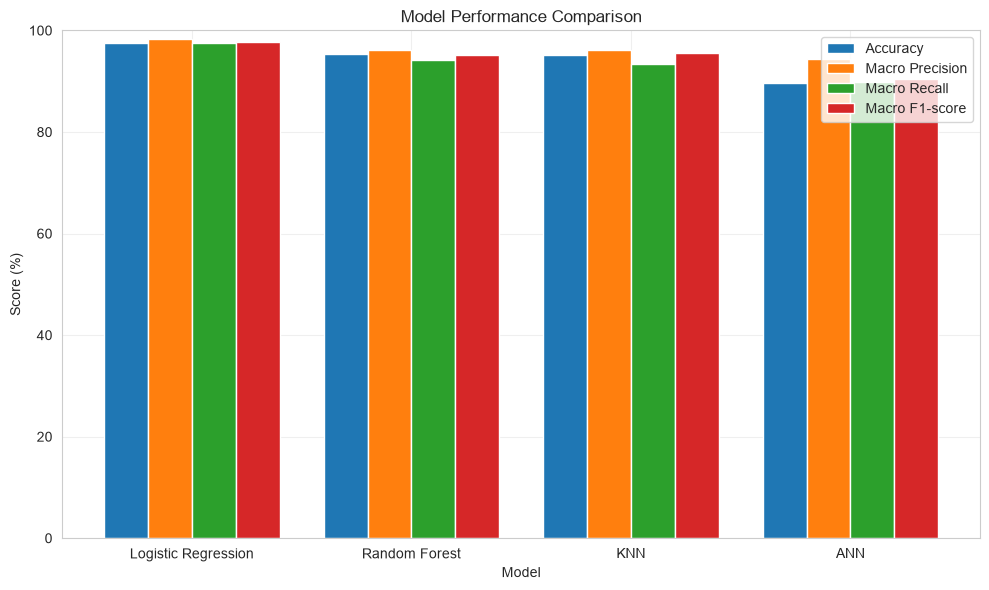

In [106]:
# Model Performance Comparison

import matplotlib.pyplot as plt
import numpy as np

models = [
    'Logistic Regression',
    'Random Forest',
    'KNN',
    'ANN'
]

accuracy = [97.44, 95.38, 95.21, 89.74]

macro_precision = [
    98.30,   # Logistic Regression
    96.21,      # Random Forest
    96.18,      # KNN
    94.36    # ANN
]

macro_recall = [
    97.45,   # Logistic Regression
    94.21,      # Random Forest
    93.32,      # KNN
    89.80       # ANN
]

macro_f1 = [
    97.78,   # Logistic Regression
    95.14,      # Random Forest
    95.49,      # KNN
    90.41    # ANN
]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - 1.5 * width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5 * width, macro_precision, width, label='Macro Precision')
plt.bar(x + 0.5 * width, macro_recall, width, label='Macro Recall')
plt.bar(x + 1.5 * width, macro_f1, width, label='Macro F1-score')

plt.xticks(x, models)
plt.ylabel('Score (%)')
plt.xlabel('Model')
plt.title('Model Performance Comparison')
plt.ylim(0, 100)

plt.legend()

plt.tight_layout()
plt.show()

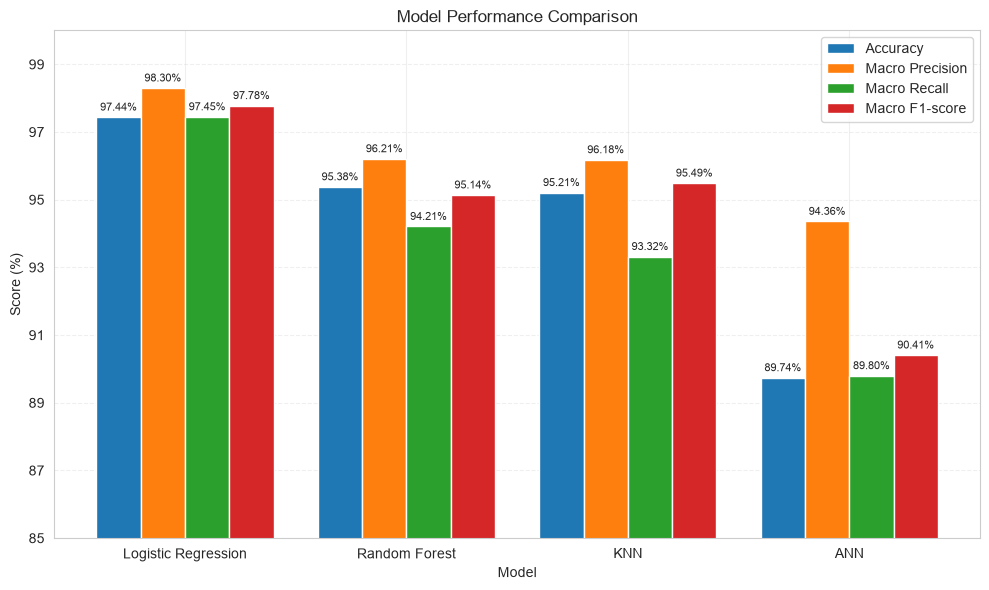

In [107]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    'Logistic Regression',
    'Random Forest',
    'KNN',
    'ANN'
]

accuracy = [97.44, 95.38, 95.21, 89.74]

macro_precision = [
    98.30,
    96.21,
    96.18,
    94.36
]

macro_recall = [
    97.45,
    94.21,
    93.32,
    89.80
]

macro_f1 = [
    97.78,
    95.14,
    95.49,
    90.41
]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))

# Default colours: blue, orange, green, red
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars1 = plt.bar(
    x - 1.5 * width,
    accuracy,
    width,
    label='Accuracy',
    color=colors[0]
)

bars2 = plt.bar(
    x - 0.5 * width,
    macro_precision,
    width,
    label='Macro Precision',
    color=colors[1]
)

bars3 = plt.bar(
    x + 0.5 * width,
    macro_recall,
    width,
    label='Macro Recall',
    color=colors[2]
)

bars4 = plt.bar(
    x + 1.5 * width,
    macro_f1,
    width,
    label='Macro F1-score',
    color=colors[3]
)

# Display values on top of bars
plt.bar_label(bars1, fmt='%.2f%%', padding=3, fontsize=8)
plt.bar_label(bars2, fmt='%.2f%%', padding=3, fontsize=8)
plt.bar_label(bars3, fmt='%.2f%%', padding=3, fontsize=8)
plt.bar_label(bars4, fmt='%.2f%%', padding=3, fontsize=8)

plt.xticks(x, models)
plt.ylabel('Score (%)')
plt.xlabel('Model')
plt.title('Model Performance Comparison')

# Make differences more visible
plt.ylim(85, 100)
plt.yticks(np.arange(85, 101, 2))

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()


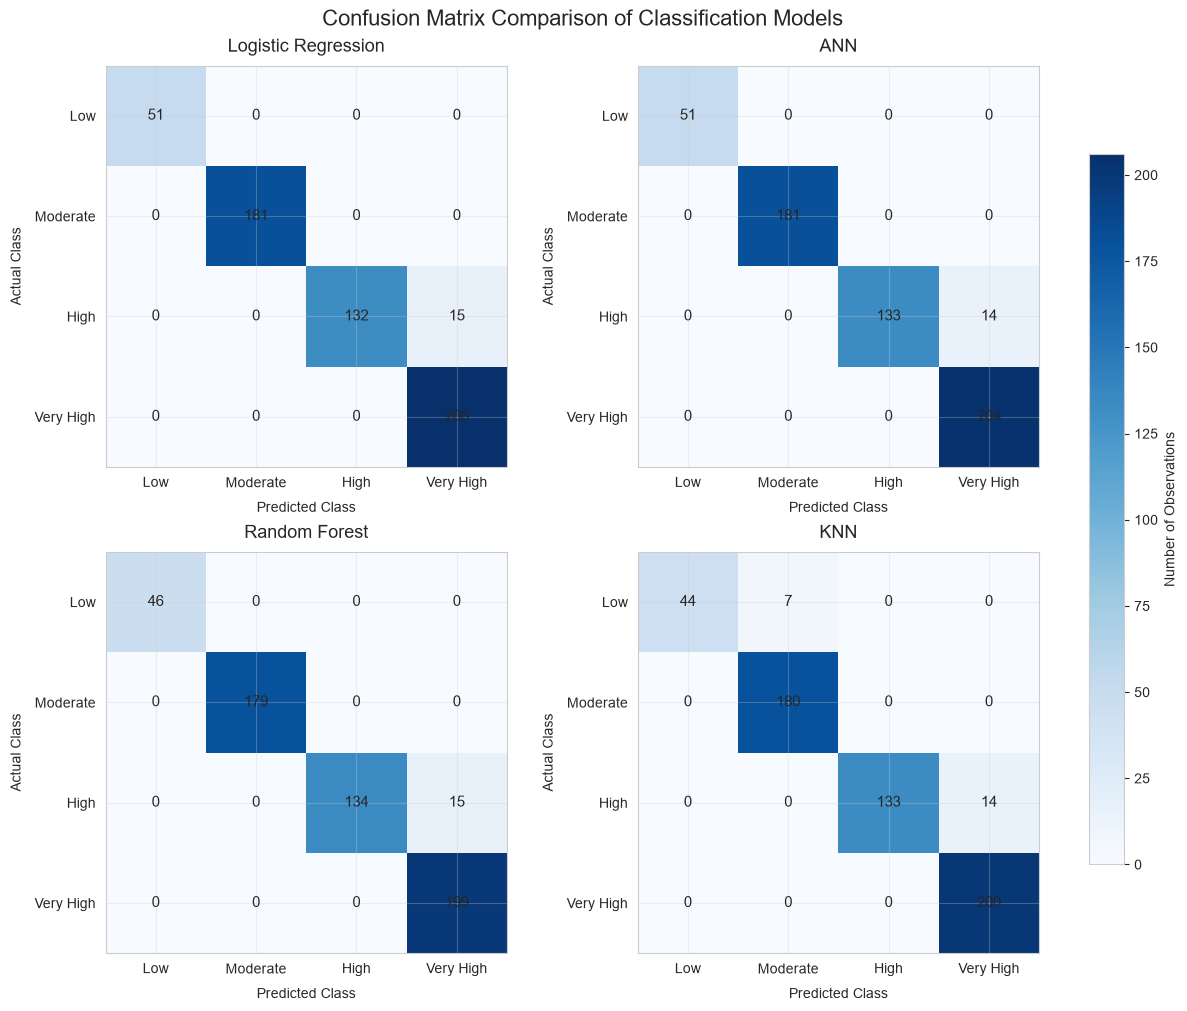

In [104]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['Low', 'Moderate', 'High', 'Very High']

confusion_matrices = {
    'Logistic Regression': np.array([
        [51, 0, 0, 0],
        [0, 181, 0, 0],
        [0, 0, 132, 15],
        [0, 0, 0, 206]
    ]),

    'ANN': np.array([
        [51, 0, 0, 0],
        [0, 181, 0, 0],
        [0, 0, 133, 14],
        [0, 0, 0, 204]
    ]),

    'Random Forest': np.array([
        [46, 0, 0, 0],
        [0, 179, 0, 0],
        [0, 0, 134, 15],
        [0, 0, 0, 199]
    ]),

    'KNN': np.array([
        [44, 7, 0, 0],
        [0, 180, 0, 0],
        [0, 0, 133, 14],
        [0, 0, 0, 200]
    ])
}

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    constrained_layout=True
)

vmax = max(cm.max() for cm in confusion_matrices.values())

for ax, (model, cm) in zip(axes.flat, confusion_matrices.items()):

    im = ax.imshow(
        cm,
        cmap='Blues',
        vmin=0,
        vmax=vmax
    )

    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))

    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)

    ax.set_xlabel('Predicted Class', labelpad=8)
    ax.set_ylabel('Actual Class', labelpad=8)
    ax.set_title(model, fontsize=13, pad=10)

    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(
                j,
                i,
                cm[i, j],
                ha='center',
                va='center',
                fontsize=11
            )

fig.suptitle(
    'Confusion Matrix Comparison of Classification Models',
    fontsize=16
)

fig.colorbar(
    im,
    ax=axes,
    label='Number of Observations',
    shrink=0.8
)

plt.show()

In [105]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score

class_labels = [
    "Low",
    "Moderate",
    "High",
    "Very High"
]

# Get predicted probabilities from the final Logistic Regression model
y_score = final_lr.predict_proba(X_test)

# Convert actual classes into binary format
y_test_bin = label_binarize(
    y_test,
    classes=class_labels
)

# Calculate ROC curve and AUC for each class
fpr = {}
tpr = {}
auc_scores = {}

for i, class_name in enumerate(class_labels):

    fpr[class_name], tpr[class_name], _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    auc_scores[class_name] = roc_auc_score(
        y_test_bin[:, i],
        y_score[:, i]
    )

# Calculate Macro-average AUC
macro_auc = roc_auc_score(
    y_test_bin,
    y_score,
    average="macro",
    multi_class="ovr"
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

for class_name in class_labels:

    plt.plot(
        fpr[class_name],
        tpr[class_name],
        linewidth=2,
        label=f"{class_name} (AUC = {auc_scores[class_name]:.4f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Multiclass ROC Curves — Final Logistic Regression"
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Display AUC results
# ------------------------------------------------------------

print("ROC-AUC Results")
print("=" * 40)

for class_name in class_labels:
    print(
        f"{class_name}: "
        f"{auc_scores[class_name]:.4f}"
    )

print(
    f"Macro-average AUC: {macro_auc:.4f}"
)

NameError: name 'final_lr' is not defined